In [ ]:
# Ejemplo extraido del libro "Algoritmos genéticos con Python" de Daniel Gutiérrez Reina y otros
# https://alfaomegaeditor.com.ar/producto/libros-algoritmos-geneticos-con-python/
# https://baobabsoluciones.es/blog/2020/10/01/problema-del-viajante/
# https://towardsdatascience.com/solving-geographic-travelling-salesman-problems-using-python-e57284b14cd7
# https://codingornot.com/08-agente-viajero-algoritmo-genetico
# https://deap.readthedocs.io/en/master/

!pip install deap
import random
import json
import numpy
import matplotlib.pyplot as plt
from deap import algorithms
from deap import base
from deap import creator
from deap import tools
from google.colab import files

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 7.7 MB/s eta 0:00:00


In [ ]:
files.upload()

Saving gr17.json to gr17.json


{'gr17.json': b'{\r\n"TourSize" : 17,\r\n"OptTour" : [15, 11, 8, 4, 1, 9, 10, 2, 14, 13, 16, 5, 7, 6, 12, 3, 0],\r\n"OptDistance" : 2085,\r\n"DistanceMatrix" :\r\n    [[0, 633, 257, 91, 412, 150, 80, 134, 259, 505, 353, 324, 70, 211, 268, 246, 121],\r\n    [633, 0, 390, 661, 227, 488, 572, 530, 555, 289, 282, 638, 567, 466, 420, 745, 518],\r\n    [257, 390, 0, 228, 169, 112, 196, 154, 372, 262, 110, 437, 191, 74, 53, 472, 142],\r\n    [91, 661, 228, 0, 383, 120, 77, 105, 175, 476, 324, 240, 27, 182, 239, 237, 84],\r\n    [412, 227, 169, 383, 0, 267, 351, 309, 338, 196, 61, 421, 346, 243, 199, 528, 297],\r\n    [150, 488, 112, 120, 267, 0, 63, 34, 264, 360, 208, 329, 83, 105, 123, 364, 35],\r\n    [80, 572, 196, 77, 351, 63, 0, 29, 232, 444, 292, 297, 47, 150, 207, 332, 29],\r\n    [134, 530, 154, 105, 309, 34, 29, 0, 249, 402, 250, 314, 68, 108, 165, 349, 36],\r\n    [259, 555, 372, 175, 338, 264, 232, 249, 0, 495, 352, 95, 189, 326, 383, 202, 236],\r\n    [505, 289, 262, 476, 196, 360

In [ ]:
url='https://github.com/palasatenea66/DATASETS/raw/main/gr120.json'
!wget $url

--2025-02-12 00:29:17--  https://github.com/palasatenea66/DATASETS/raw/main/gr120.json
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/palasatenea66/DATASETS/main/gr120.json [following]
--2025-02-12 00:29:17--  https://raw.githubusercontent.com/palasatenea66/DATASETS/main/gr120.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 72474 (71K) [text/plain]
Saving to: ‘gr120.json’

gr120.json          100%[===================>]  70.78K  --.-KB/s    in 0.003s  

2025-02-12 00:29:17 (22.9 MB/s) - ‘gr120.json’ saved [72474/72474]



In [ ]:
!ls

EvolucionTSP.eps  gr120.json  gr17.json  gr17.json.1  sample_data


In [ ]:
# gr*.json contiene el mapa de distancias entre ciudades en formato JSON
with open("gr120.json", "r") as tsp_data:
    tsp = json.load(tsp_data)


In [ ]:
tsp

{'TourSize': 120,
 'OptTour': [1,
  76,
  59,
  15,
  30,
  29,
  120,
  32,
  92,
  28,
  45,
  78,
  86,
  94,
  81,
  22,
  66,
  31,
  117,
  85,
  18,
  19,
  25,
  108,
  43,
  79,
  52,
  33,
  100,
  58,
  91,
  68,
  65,
  69,
  113,
  107,
  20,
  46,
  50,
  44,
  75,
  14,
  87,
  74,
  105,
  40,
  72,
  38,
  7,
  56,
  41,
  42,
  98,
  17,
  118,
  49,
  13,
  51,
  11,
  23,
  9,
  103,
  119,
  3,
  82,
  2,
  115,
  21,
  93,
  53,
  64,
  109,
  88,
  97,
  12,
  95,
  77,
  39,
  63,
  5,
  27,
  80,
  101,
  102,
  48,
  110,
  112,
  106,
  114,
  73,
  57,
  83,
  67,
  37,
  62,
  99,
  10,
  35,
  104,
  36,
  84,
  6,
  89,
  55,
  47,
  71,
  26,
  4,
  34,
  116,
  70,
  8,
  54,
  90,
  96,
  111,
  24,
  60,
  16,
  61],
 'OptDistance': 6942,
 'DistanceMatrix': [[0,
   534,
   434,
   294,
   593,
   409,
   332,
   232,
   464,
   566,
   552,
   802,
   633,
   257,
   187,
   91,
   412,
   400,
   472,
   389,
   610,
   340,
   510,
   153,
   511,
 

In [ ]:
# matriz de distancia
distance_map = tsp["DistanceMatrix"]
# número de ciudades que visitar
IND_SIZE = tsp["TourSize"]


In [ ]:
distance_map

[[0,
  633,
  257,
  91,
  412,
  150,
  80,
  134,
  259,
  505,
  353,
  324,
  70,
  211,
  268,
  246,
  121],
 [633,
  0,
  390,
  661,
  227,
  488,
  572,
  530,
  555,
  289,
  282,
  638,
  567,
  466,
  420,
  745,
  518],
 [257,
  390,
  0,
  228,
  169,
  112,
  196,
  154,
  372,
  262,
  110,
  437,
  191,
  74,
  53,
  472,
  142],
 [91,
  661,
  228,
  0,
  383,
  120,
  77,
  105,
  175,
  476,
  324,
  240,
  27,
  182,
  239,
  237,
  84],
 [412,
  227,
  169,
  383,
  0,
  267,
  351,
  309,
  338,
  196,
  61,
  421,
  346,
  243,
  199,
  528,
  297],
 [150,
  488,
  112,
  120,
  267,
  0,
  63,
  34,
  264,
  360,
  208,
  329,
  83,
  105,
  123,
  364,
  35],
 [80, 572, 196, 77, 351, 63, 0, 29, 232, 444, 292, 297, 47, 150, 207, 332, 29],
 [134,
  530,
  154,
  105,
  309,
  34,
  29,
  0,
  249,
  402,
  250,
  314,
  68,
  108,
  165,
  349,
  36],
 [259,
  555,
  372,
  175,
  338,
  264,
  232,
  249,
  0,
  495,
  352,
  95,
  189,
  326,
  383,
  202,
  2

In [ ]:
IND_SIZE

120

In [ ]:
def evalTSP(individual):
    """ Función objetivo, calcula la distancia que recorre el viajante"""
    # distancia entre el último elemento y el primero
    distance = distance_map[individual[-1]][individual[0]]
    # distancia entre el resto de ciudades
    for gene1, gene2 in zip(individual[0:-1], individual[1:]):
        distance += distance_map[gene1][gene2]
    return distance,


In [ ]:
def plot_evolucion(log):
    gen = log.select("gen")
    fit_mins = log.select("min")
    fit_maxs = log.select("max")
    fit_ave = log.select("avg")

    fig, ax1 = plt.subplots()
    ax1.plot(gen, fit_mins, "b")
    ax1.plot(gen, fit_maxs, "r")
    ax1.plot(gen, fit_ave, "--k")
    '''
    ax1.fill_between(gen, fit_mins, fit_maxs,
                     where=fit_maxs >= fit_mins,
                     facecolor="g", alpha=0.2)'''
    ax1.set_xlabel("Generación")
    ax1.set_ylabel("Fitness")
    ax1.legend(["Min", "Max", "Avg"])
    ax1.set_ylim([5000, 50000])
    plt.grid(True)
    plt.savefig("EvolucionTSP.eps", dpi=300)

In [ ]:
def main():
    #random.seed(100)
    CXPB, MUTPB, NGEN = 0.6, 0.4, 2000
    pop = toolbox.population()
    MU, LAMBDA = len(pop), len(pop)
    hof = tools.HallOfFame(1)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", numpy.mean)
    stats.register("std", numpy.std)
    stats.register("min", numpy.min)
    stats.register("max", numpy.max)
    logbook = tools.Logbook()
    pop, logbook = algorithms.eaMuPlusLambda(pop, toolbox, MU,
                                             LAMBDA, CXPB, MUTPB,
                                             NGEN, stats=stats,
                                             halloffame=hof)
    return hof, logbook

In [ ]:
# Creamos los objetos para definir el problema y el tipo de individuo
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

/usr/local/lib/python3.11/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.11/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [ ]:
toolbox = base.Toolbox()
# Generación de un tour aleatorio
toolbox.register("indices", random.sample, range(IND_SIZE), IND_SIZE)

# Generación de inviduos y población
toolbox.register("individual", tools.initIterate, creator.Individual,
                 toolbox.indices)
toolbox.register("population", tools.initRepeat, list,
                 toolbox.individual, 100)

In [ ]:
# registro de operaciones genéticas
toolbox.register("mate", tools.cxOrdered)
toolbox.register("mutate", tools.mutShuffleIndexes, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("evaluate", evalTSP)


In [ ]:
best, log = main()
print("Mejor fitness: %f" %best[0].fitness.values)
print("Mejor individuo %s" %best[0])


gen	nevals	avg    	std    	min  	max  
0  	100   	52329.3	2295.73	46189	58206
1  	100   	50609.8	1951.9 	46189	55203
2  	100   	49055.4	1489.84	45371	51946
3  	100   	47811.4	1364.68	45371	51310
4  	100   	46470.3	1260.25	42839	50032
5  	100   	45337.9	1156.02	41905	47683
6  	100   	44333.5	1026.1 	41905	47438
7  	100   	43877  	852.814	42050	46938
8  	100   	43417.3	813.535	41724	44970
9  	100   	42775.2	1028.41	39708	46089
10 	100   	42120.9	827.141	39708	43853
11 	100   	41626  	757.955	39708	43599
12 	100   	41040.4	1010.49	36692	43041
13 	100   	40537.7	1121.62	36692	43617
14 	100   	39928.7	874.876	36692	41946
15 	100   	39461.1	888.635	36692	41329
16 	100   	38839.8	958.026	36692	40568
17 	100   	38293.6	994.142	35699	40303
18 	100   	37638.9	886.068	35712	39677
19 	100   	37217  	927.798	34695	39669
20 	100   	36889.4	839.623	34785	39497
21 	100   	36424.7	694.404	34785	38893
22 	100   	36186.2	787.109	34222	38379
23 	100   	36013.5	738.679	34222	38377
24 	100   	35746.1	742.67

In [ ]:
tsp['OptTour']

[1,
 76,
 59,
 15,
 30,
 29,
 120,
 32,
 92,
 28,
 45,
 78,
 86,
 94,
 81,
 22,
 66,
 31,
 117,
 85,
 18,
 19,
 25,
 108,
 43,
 79,
 52,
 33,
 100,
 58,
 91,
 68,
 65,
 69,
 113,
 107,
 20,
 46,
 50,
 44,
 75,
 14,
 87,
 74,
 105,
 40,
 72,
 38,
 7,
 56,
 41,
 42,
 98,
 17,
 118,
 49,
 13,
 51,
 11,
 23,
 9,
 103,
 119,
 3,
 82,
 2,
 115,
 21,
 93,
 53,
 64,
 109,
 88,
 97,
 12,
 95,
 77,
 39,
 63,
 5,
 27,
 80,
 101,
 102,
 48,
 110,
 112,
 106,
 114,
 73,
 57,
 83,
 67,
 37,
 62,
 99,
 10,
 35,
 104,
 36,
 84,
 6,
 89,
 55,
 47,
 71,
 26,
 4,
 34,
 116,
 70,
 8,
 54,
 90,
 96,
 111,
 24,
 60,
 16,
 61]

In [ ]:
tsp['OptDistance']

6942

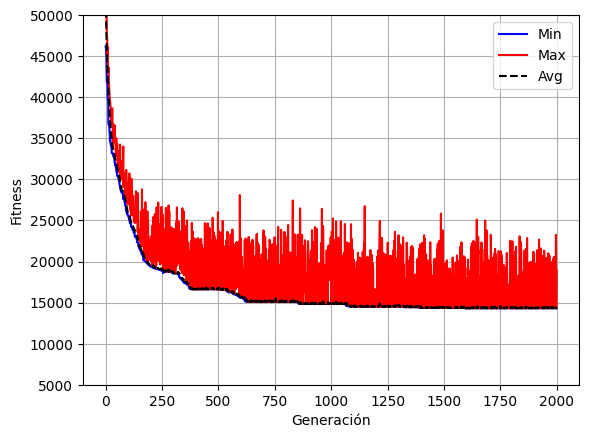

In [ ]:
plot_evolucion(log)

In [ ]:
log

[{'gen': 0,
  'nevals': 100,
  'avg': 52329.32,
  'std': 2295.7316039990387,
  'min': 46189.0,
  'max': 58206.0},
 {'gen': 1,
  'nevals': 100,
  'avg': 50609.83,
  'std': 1951.9049262451285,
  'min': 46189.0,
  'max': 55203.0},
 {'gen': 2,
  'nevals': 100,
  'avg': 49055.4,
  'std': 1489.8399914084732,
  'min': 45371.0,
  'max': 51946.0},
 {'gen': 3,
  'nevals': 100,
  'avg': 47811.42,
  'std': 1364.6792456837613,
  'min': 45371.0,
  'max': 51310.0},
 {'gen': 4,
  'nevals': 100,
  'avg': 46470.28,
  'std': 1260.2468177305586,
  'min': 42839.0,
  'max': 50032.0},
 {'gen': 5,
  'nevals': 100,
  'avg': 45337.86,
  'std': 1156.024230022883,
  'min': 41905.0,
  'max': 47683.0},
 {'gen': 6,
  'nevals': 100,
  'avg': 44333.54,
  'std': 1026.099375499274,
  'min': 41905.0,
  'max': 47438.0},
 {'gen': 7,
  'nevals': 100,
  'avg': 43876.99,
  'std': 852.8144991145496,
  'min': 42050.0,
  'max': 46938.0},
 {'gen': 8,
  'nevals': 100,
  'avg': 43417.32,
  'std': 813.5352958538431,
  'min': 41724.0